In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

# ── Check ──────────────────────────────────────────────────────────────────
print(f"{'═'*45}")
print(f"  MISSING VALUE REPORT")
print(f"{'═'*45}")
print(f"{'Column':<25} {'Missing':>7}  {'%':>6}")
print(f"{'─'*45}")

for col in df.columns:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    flag = ' ⚠' if n > 0 else ''
    print(f"{col:<25} {n:>7}  {pct:>5.1f}%{flag}")

print(f"{'─'*45}")
print(f"{'Total missing cells':<25} {df.isnull().sum().sum():>7}")
print(f"{'Rows with any missing':<25} {df.isnull().any(axis=1).sum():>7}")
print(f"{'═'*45}\n")

# ── Handle ─────────────────────────────────────────────────────────────────
missing_cols = df.columns[df.isnull().any()].tolist()

if not missing_cols:
    print("✔  No missing values found. No handling required.")
else:
    print(f"Handling {len(missing_cols)} column(s) with missing values...\n")
    for col in missing_cols:
        if df[col].dtype == 'object':
            # Categorical → fill with mode
            fill_val = df[col].mode()[0]
            strategy = 'mode'
        else:
            # Numeric → fill with median (robust to outliers)
            fill_val = df[col].median()
            strategy = 'median'

        df[col].fillna(fill_val, inplace=True)
        print(f"  {col:<25} filled with {strategy} ({fill_val:.4f})")

    print(f"\n✔  Missing values after handling: {df.isnull().sum().sum()}")

print(f"\nFinal dataset shape: {df.shape}")

═════════════════════════════════════════════
  MISSING VALUE REPORT
═════════════════════════════════════════════
Column                    Missing       %
─────────────────────────────────────────────
fixed acidity                   0    0.0%
volatile acidity                0    0.0%
citric acid                     0    0.0%
residual sugar                  0    0.0%
chlorides                       0    0.0%
free sulfur dioxide             0    0.0%
total sulfur dioxide            0    0.0%
density                         0    0.0%
pH                              0    0.0%
sulphates                       0    0.0%
alcohol                         0    0.0%
quality                         0    0.0%
─────────────────────────────────────────────
Total missing cells             0
Rows with any missing           0
═════════════════════════════════════════════

✔  No missing values found. No handling required.

Final dataset shape: (1143, 12)


In [6]:
import pandas as pd

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

# ── Check ──────────────────────────────────────────────────────────────────
total_dups   = df.duplicated().sum()
pct_dups     = total_dups / len(df) * 100

print(f"{'═'*45}")
print(f"  DUPLICATE REPORT")
print(f"{'═'*45}")
print(f"  Total rows          : {len(df)}")
print(f"  Duplicate rows      : {total_dups}  ({pct_dups:.2f}%)")
print(f"  Unique rows         : {len(df) - total_dups}")
print(f"{'═'*45}\n")

if total_dups > 0:
    print("  Duplicate rows preview:")
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).to_string())
    print()

# ── Handle ─────────────────────────────────────────────────────────────────
if total_dups == 0:
    print("✔  No duplicates found. No handling required.")
else:
    df = df.drop_duplicates(keep='first')
    print(f"✔  Duplicates removed. Rows remaining: {len(df)}")

print(f"\nFinal dataset shape: {df.shape}")

═════════════════════════════════════════════
  DUPLICATE REPORT
═════════════════════════════════════════════
  Total rows          : 1143
  Duplicate rows      : 125  (10.94%)
  Unique rows         : 1018
═════════════════════════════════════════════

  Duplicate rows preview:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates    alcohol  quality
96              5.2             0.340         0.00            1.80      0.050                 27.0                  63.0  0.99160  3.68       0.79  14.000000        6
98              5.2             0.340         0.00            1.80      0.050                 27.0                  63.0  0.99160  3.68       0.79  14.000000        6
949             6.0             0.500         0.00            1.40      0.057                 15.0                  26.0  0.99448  3.36       0.45   9.500000        5
950             6.0             0.500         0.00  

══════════════════════════════════════════════════
  OUTLIER DETECTION REPORT
══════════════════════════════════════════════════
Column                       IQR     Z>3    Both
──────────────────────────────────────────────────
fixed acidity                 44       9       9
volatile acidity              14       5       5
citric acid                    1       1       1
residual sugar               110      23      23
chlorides                     77      21      21
free sulfur dioxide           18      13      13
total sulfur dioxide          40      10      10
density                       36      12      12
pH                            20       5       5
sulphates                     43      21      21
alcohol                       12       7       7
──────────────────────────────────────────────────
Rows flagged (IQR)           295
Rows flagged (Z>3)            97
Consensus (both)              97
══════════════════════════════════════════════════



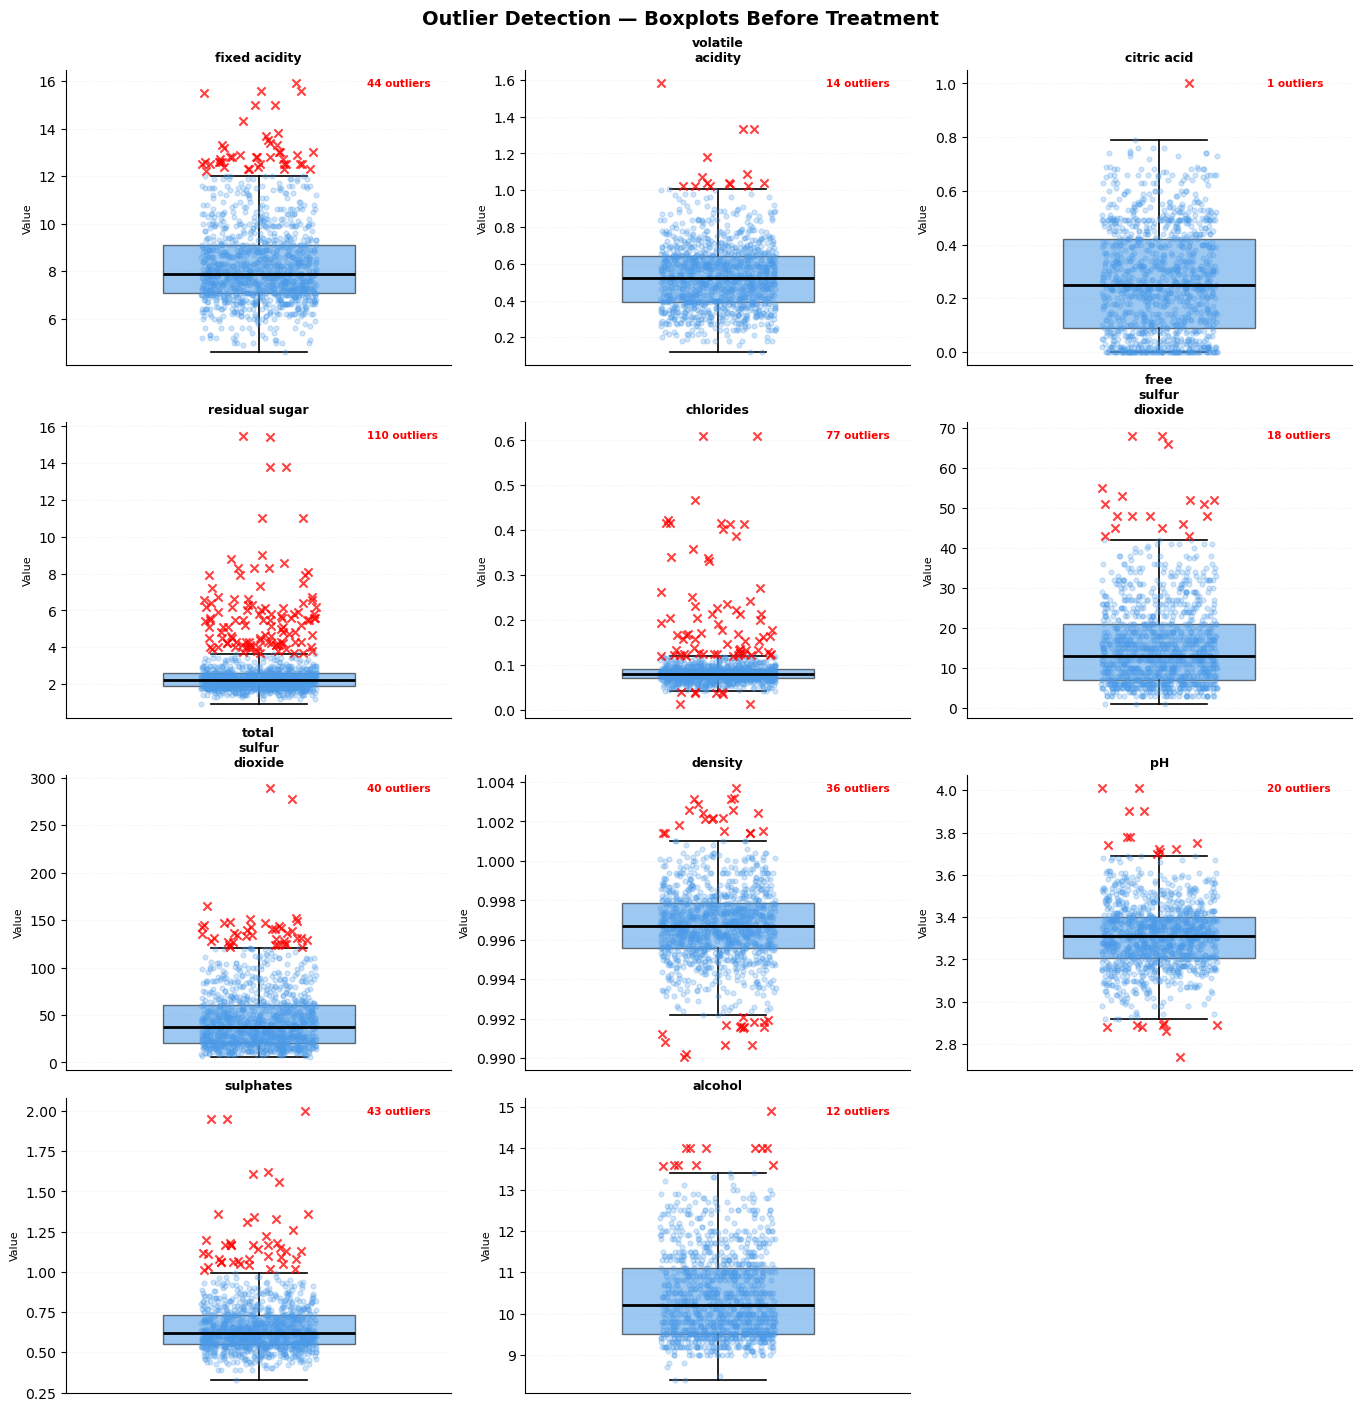

═════════════════════════════════════════════
  TREATMENT — IQR Winsorisation (clipping)
═════════════════════════════════════════════
Column                      Capped
─────────────────────────────────────────────
fixed acidity                   44
volatile acidity                14
citric acid                      1
residual sugar                 110
chlorides                       77
free sulfur dioxide             18
total sulfur dioxide            40
density                         36
pH                              20
sulphates                       43
alcohol                         12
─────────────────────────────────────────────
Total values capped            415
Rows preserved                1143
═════════════════════════════════════════════



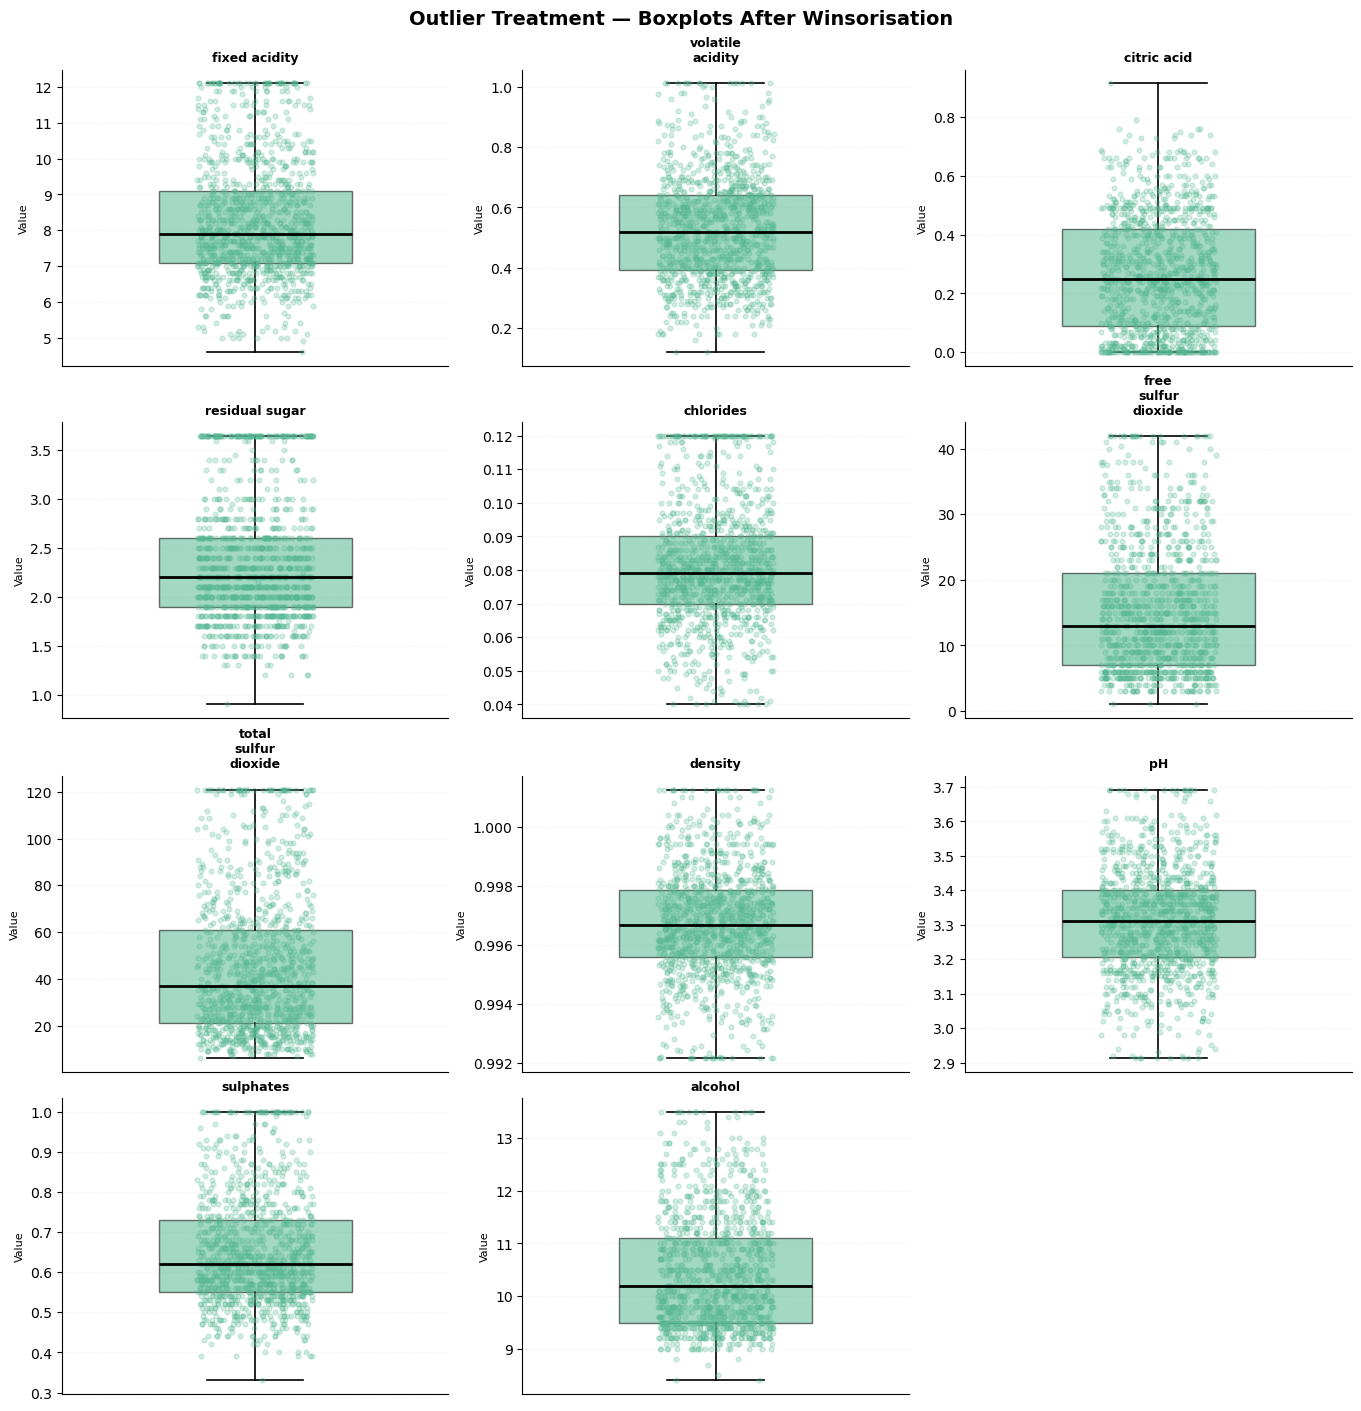

✔  Treatment complete. Use df_treated for all further analysis.
   Final shape: (1143, 12)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import ceil

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

features = [c for c in df.select_dtypes(include=np.number).columns if c != 'quality']

# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — DETECT  (IQR + Z-score)
# ══════════════════════════════════════════════════════════════════════════
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

df['outlier_iqr']    = False
df['outlier_zscore'] = False

for feat in features:
    lo, hi = iqr_bounds(df[feat])
    df.loc[(df[feat] < lo) | (df[feat] > hi), 'outlier_iqr'] = True

    z = np.abs(stats.zscore(df[feat]))
    df.loc[z > 3, 'outlier_zscore'] = True

df['outlier_consensus'] = df['outlier_iqr'] & df['outlier_zscore']

print(f"{'═'*50}")
print(f"  OUTLIER DETECTION REPORT")
print(f"{'═'*50}")
print(f"{'Column':<25} {'IQR':>6}  {'Z>3':>6}  {'Both':>6}")
print(f"{'─'*50}")

for feat in features:
    lo, hi   = iqr_bounds(df[feat])
    n_iqr    = ((df[feat] < lo) | (df[feat] > hi)).sum()
    n_z      = (np.abs(stats.zscore(df[feat])) > 3).sum()
    n_both   = (((df[feat] < lo) | (df[feat] > hi)) &
                (np.abs(stats.zscore(df[feat])) > 3)).sum()
    print(f"{feat:<25} {n_iqr:>6}  {n_z:>6}  {n_both:>6}")

print(f"{'─'*50}")
print(f"{'Rows flagged (IQR)':<25} {df['outlier_iqr'].sum():>6}")
print(f"{'Rows flagged (Z>3)':<25} {df['outlier_zscore'].sum():>6}")
print(f"{'Consensus (both)':<25} {df['outlier_consensus'].sum():>6}")
print(f"{'═'*50}\n")

# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — VISUALISE before treatment
# ══════════════════════════════════════════════════════════════════════════
NCOLS = 3
NROWS = ceil(len(features) / NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 4.5, NROWS * 3.5),
                         constrained_layout=True)
axes = np.array(axes).flatten()
fig.suptitle('Outlier Detection — Boxplots Before Treatment',
             fontsize=14, fontweight='bold')

for i, feat in enumerate(features):
    ax  = axes[i]
    lo, hi = iqr_bounds(df[feat])
    data   = df[feat]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp['boxes'][0].set_facecolor('#4C9BE8')
    bp['boxes'][0].set_alpha(0.55)

    # inliers
    inliers  = data[(data >= lo) & (data <= hi)]
    outliers = data[(data <  lo) | (data >  hi)]
    ax.scatter(np.random.uniform(0.85, 1.15, len(inliers)),
               inliers, color='#4C9BE8', alpha=0.25, s=12, zorder=2)
    ax.scatter(np.random.uniform(0.85, 1.15, len(outliers)),
               outliers, color='red', alpha=0.75, s=35,
               marker='x', linewidths=1.5, zorder=5)

    if len(outliers):
        ax.text(1.28, outliers.max(),
                f'{len(outliers)} outliers', va='center',
                fontsize=7.5, color='red', fontweight='bold')

    ax.set_title(feat.replace(' ', '\n') if len(feat) > 15 else feat,
                 fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Value', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle=':')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.savefig('outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — TREAT  (IQR Capping / Winsorisation)
# ══════════════════════════════════════════════════════════════════════════
# Strategy: cap values to the IQR whisker bounds (Winsorisation)
# Preserves row count — better than dropping for a 1143-row dataset

df_treated = df.drop(columns=['outlier_iqr', 'outlier_zscore', 'outlier_consensus']).copy()

capped = {}
for feat in features:
    lo, hi    = iqr_bounds(df[feat])
    n_capped  = ((df[feat] < lo) | (df[feat] > hi)).sum()
    df_treated[feat] = df[feat].clip(lower=lo, upper=hi)
    capped[feat]     = n_capped

print(f"{'═'*45}")
print(f"  TREATMENT — IQR Winsorisation (clipping)")
print(f"{'═'*45}")
print(f"{'Column':<25} {'Capped':>8}")
print(f"{'─'*45}")
for feat, n in capped.items():
    print(f"{feat:<25} {n:>8}")
print(f"{'─'*45}")
print(f"{'Total values capped':<25} {sum(capped.values()):>8}")
print(f"{'Rows preserved':<25} {len(df_treated):>8}")
print(f"{'═'*45}\n")

# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — VISUALISE after treatment
# ══════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 4.5, NROWS * 3.5),
                            constrained_layout=True)
axes2 = np.array(axes2).flatten()
fig2.suptitle('Outlier Treatment — Boxplots After Winsorisation',
              fontsize=14, fontweight='bold')

for i, feat in enumerate(features):
    ax  = axes2[i]
    lo, hi = iqr_bounds(df[feat])
    data   = df_treated[feat]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp['boxes'][0].set_facecolor('#57B894')
    bp['boxes'][0].set_alpha(0.55)

    ax.scatter(np.random.uniform(0.85, 1.15, len(data)),
               data, color='#57B894', alpha=0.25, s=12, zorder=2)

    ax.set_title(feat.replace(' ', '\n') if len(feat) > 15 else feat,
                 fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Value', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle=':')

for j in range(len(features), len(axes2)):
    axes2[j].set_visible(False)

plt.savefig('outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("✔  Treatment complete. Use df_treated for all further analysis.")
print(f"   Final shape: {df_treated.shape}")

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

# ── Check for categorical columns ──────────────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"{'═'*45}")
print(f"  CATEGORICAL VARIABLE CHECK")
print(f"{'═'*45}")
print(f"  Total columns       : {df.shape[1]}")
print(f"  Numeric columns     : {len(num_cols)}")
print(f"  Categorical columns : {len(cat_cols)}")
print(f"{'─'*45}")

if not cat_cols:
    print("  ✔  No categorical columns found.")
    print("     All features are already numeric.")
    print("     No encoding required.")
else:
    for col in cat_cols:
        print(f"  {col:<20} unique values: {df[col].nunique()}")
        print(f"  {'':<20} {df[col].unique()}")

print(f"{'═'*45}\n")
print(df.dtypes)

═════════════════════════════════════════════
  CATEGORICAL VARIABLE CHECK
═════════════════════════════════════════════
  Total columns       : 12
  Numeric columns     : 12
  Categorical columns : 0
─────────────────────────────────────────────
  ✔  No categorical columns found.
     All features are already numeric.
     No encoding required.
═════════════════════════════════════════════

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


══════════════════════════════════════════════════════════════
  FEATURE SCALING REPORT
══════════════════════════════════════════════════════════════
Feature                       Min      Max     Mean      Std
──────────────────────────────────────────────────────────────

  ── Before scaling ──
  fixed acidity             4.600   12.100    8.270    1.630
  volatile acidity          0.120    1.011    0.530    0.174
  citric acid               0.000    0.915    0.268    0.196
  residual sugar            0.900    3.650    2.323    0.610
  chlorides                 0.040    0.120    0.081    0.018
  free sulfur dioxide       1.000   42.000   15.463    9.726
  total sulfur dioxide      6.000  121.000   45.127   29.975
  density                   0.992    1.001    0.997    0.002
  pH                        2.913    3.692    3.310    0.152
  sulphates                 0.330    1.000    0.649    0.136
  alcohol                   8.400   13.500   10.438    1.069

  ── After StandardScaler ──


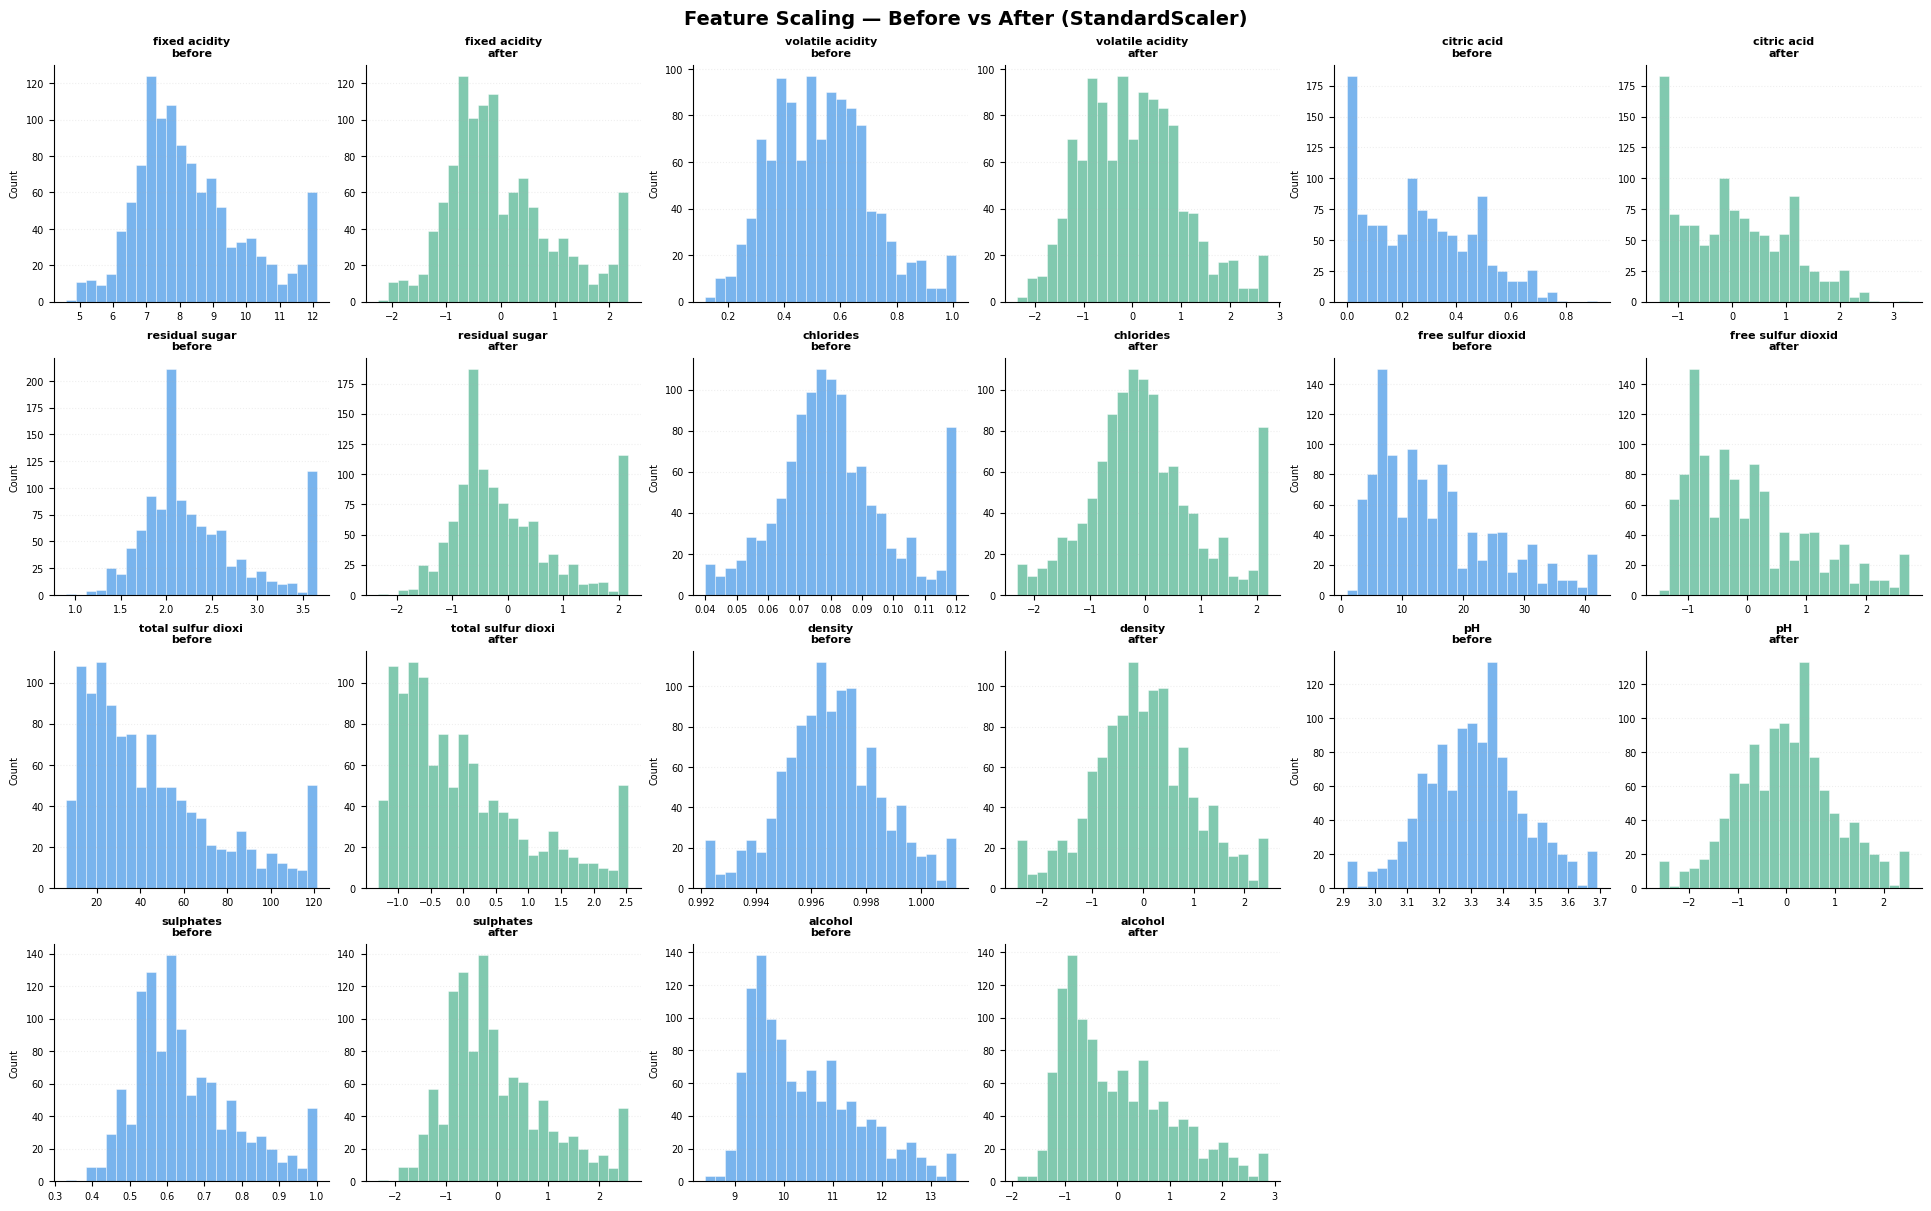

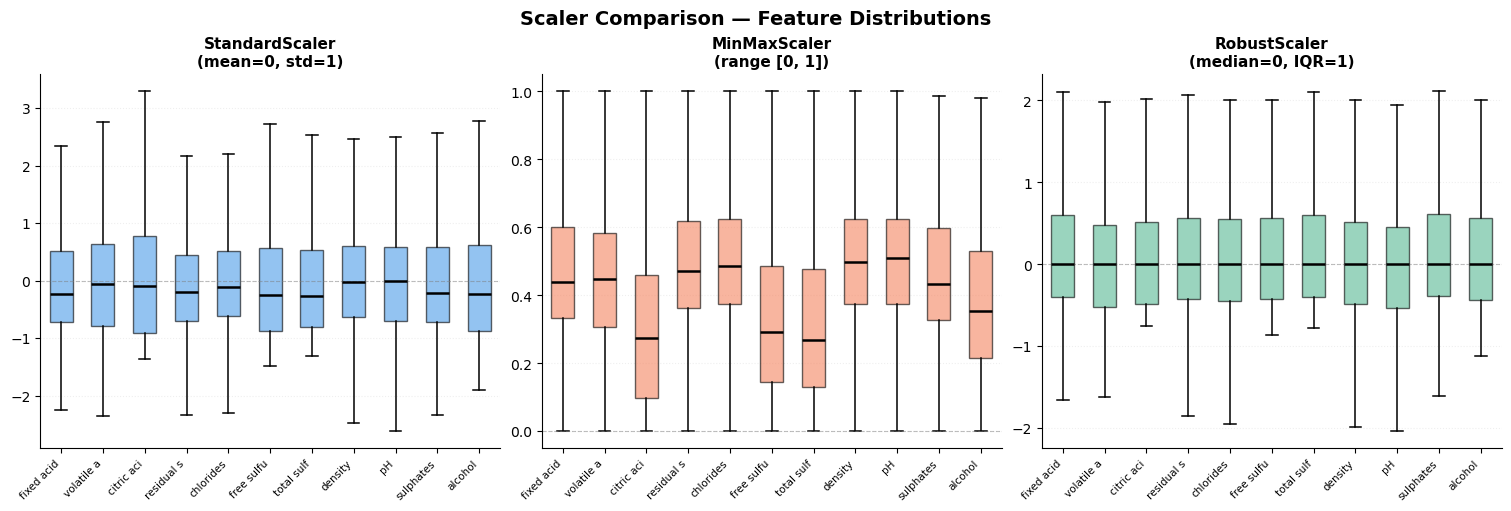

✔  Scaling complete using StandardScaler.
   Features scaled : 11
   Target kept as-is: quality (not scaled)
   Final shape     : (1143, 12)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from math import ceil
from scipy import stats

df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

# ── Apply outlier treatment first (Winsorisation) ──────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

features = [c for c in df.select_dtypes(include=np.number).columns if c != 'quality']

for feat in features:
    lo, hi = iqr_bounds(df[feat])
    df[feat] = df[feat].clip(lower=lo, upper=hi)

# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — CHOOSE SCALER
# ══════════════════════════════════════════════════════════════════════════
# StandardScaler  → best when features are approx. normal, no extreme outliers
# MinMaxScaler    → best when you need values in [0, 1], e.g. neural networks
# RobustScaler    → best when outliers are still present (uses median/IQR)
#
# WineQT: after Winsorisation, StandardScaler is appropriate.
# All three are shown for comparison.

X = df[features]
y = df['quality']

std_scaler    = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_standard = pd.DataFrame(std_scaler.fit_transform(X),    columns=features)
X_minmax   = pd.DataFrame(minmax_scaler.fit_transform(X), columns=features)
X_robust   = pd.DataFrame(robust_scaler.fit_transform(X), columns=features)

# ── Stats comparison ───────────────────────────────────────────────────────
print(f"{'═'*62}")
print(f"  FEATURE SCALING REPORT")
print(f"{'═'*62}")
print(f"{'Feature':<25} {'Min':>7}  {'Max':>7}  {'Mean':>7}  {'Std':>7}")
print(f"{'─'*62}")

print("\n  ── Before scaling ──")
for feat in features:
    print(f"  {feat:<23} {df[feat].min():>7.3f}  {df[feat].max():>7.3f}"
          f"  {df[feat].mean():>7.3f}  {df[feat].std():>7.3f}")

print("\n  ── After StandardScaler ──")
for feat in features:
    print(f"  {feat:<23} {X_standard[feat].min():>7.3f}  {X_standard[feat].max():>7.3f}"
          f"  {X_standard[feat].mean():>7.3f}  {X_standard[feat].std():>7.3f}")

print("\n  ── After MinMaxScaler ──")
for feat in features:
    print(f"  {feat:<23} {X_minmax[feat].min():>7.3f}  {X_minmax[feat].max():>7.3f}"
          f"  {X_minmax[feat].mean():>7.3f}  {X_minmax[feat].std():>7.3f}")

print(f"\n{'═'*62}\n")

# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — VISUALISE: before vs after (StandardScaler)
# ══════════════════════════════════════════════════════════════════════════
NCOLS = 3
NROWS = ceil(len(features) / NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS * 2,
                         figsize=(NCOLS * 2 * 3.2, NROWS * 3),
                         constrained_layout=True)
fig.suptitle('Feature Scaling — Before vs After (StandardScaler)',
             fontsize=14, fontweight='bold')

for i, feat in enumerate(features):
    row  = i // NCOLS
    col  = (i %  NCOLS) * 2

    # Before
    ax_before = axes[row, col]
    ax_before.hist(df[feat], bins=25, color='#4C9BE8',
                   alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_before.set_title(f'{feat[:18]}\nbefore', fontsize=8, fontweight='bold')
    ax_before.set_ylabel('Count', fontsize=7)
    ax_before.spines[['top', 'right']].set_visible(False)
    ax_before.tick_params(labelsize=7)
    ax_before.grid(axis='y', alpha=0.2, linestyle=':')

    # After
    ax_after = axes[row, col + 1]
    ax_after.hist(X_standard[feat], bins=25, color='#57B894',
                  alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_after.set_title(f'{feat[:18]}\nafter', fontsize=8, fontweight='bold')
    ax_after.spines[['top', 'right']].set_visible(False)
    ax_after.tick_params(labelsize=7)
    ax_after.grid(axis='y', alpha=0.2, linestyle=':')

# Hide unused
for r in range(NROWS):
    for c in range(NCOLS * 2):
        idx = (r * NCOLS) + (c // 2)
        if idx >= len(features):
            axes[r, c].set_visible(False)

plt.savefig('scaling_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — VISUALISE: scaler comparison (boxplots)
# ══════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig2.suptitle('Scaler Comparison — Feature Distributions',
              fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
        axes2,
        [X_standard, X_minmax, X_robust],
        ['StandardScaler\n(mean=0, std=1)',
         'MinMaxScaler\n(range [0, 1])',
         'RobustScaler\n(median=0, IQR=1)'],
        ['#4C9BE8', '#F4845F', '#57B894']):

    bp = ax.boxplot([data[f].values for f in features],
                    patch_artist=True,
                    widths=0.55,
                    showfliers=False,
                    medianprops=dict(color='black', linewidth=1.8),
                    whiskerprops=dict(linewidth=1.1),
                    capprops=dict(linewidth=1.1))

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.60)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, len(features) + 1))
    ax.set_xticklabels([f[:10] for f in features],
                       rotation=45, ha='right', fontsize=7.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle=':')

plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — FINAL SCALED DATASET
# ══════════════════════════════════════════════════════════════════════════
df_scaled          = X_standard.copy()
df_scaled['quality'] = y.values

print(f"✔  Scaling complete using StandardScaler.")
print(f"   Features scaled : {len(features)}")
print(f"   Target kept as-is: quality (not scaled)")
print(f"   Final shape     : {df_scaled.shape}")

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

# ── Load & prep ────────────────────────────────────────────────────────────
df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

# Winsorisation
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

features = [c for c in df.select_dtypes(include=np.number).columns if c != 'quality']

for feat in features:
    lo, hi = iqr_bounds(df[feat])
    df[feat] = df[feat].clip(lower=lo, upper=hi)

# Scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
y = df['quality']

# ══════════════════════════════════════════════════════════════════════════
# SPLIT
# ══════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,       # 80% train — 20% test
    random_state = 42,        # reproducibility
    stratify     = y          # preserve class distribution
)

# ══════════════════════════════════════════════════════════════════════════
# REPORT
# ══════════════════════════════════════════════════════════════════════════
print(f"{'═'*50}")
print(f"  TRAIN / TEST SPLIT REPORT")
print(f"{'═'*50}")
print(f"  Total samples   : {len(X)}")
print(f"  Train samples   : {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test  samples   : {len(X_test)}   ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Features        : {X.shape[1]}")
print(f"  Random state    : 42")
print(f"  Stratified      : yes")
print(f"{'═'*50}\n")

# ── Class distribution check ───────────────────────────────────────────────
print(f"{'─'*50}")
print(f"  TARGET DISTRIBUTION — quality score")
print(f"{'─'*50}")
print(f"  {'Class':<10} {'Full':>8}  {'Train':>8}  {'Test':>8}")
print(f"  {'─'*44}")

for cls in sorted(y.unique()):
    n_full  = (y        == cls).sum()
    n_train = (y_train  == cls).sum()
    n_test  = (y_test   == cls).sum()
    pct_full  = n_full  / len(y)        * 100
    pct_train = n_train / len(y_train)  * 100
    pct_test  = n_test  / len(y_test)   * 100
    print(f"  quality={cls}  "
          f"{n_full:>4} ({pct_full:4.1f}%)  "
          f"{n_train:>4} ({pct_train:4.1f}%)  "
          f"{n_test:>4} ({pct_test:4.1f}%)")

print(f"{'─'*50}\n")

# ── Shape summary ──────────────────────────────────────────────────────────
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")
print(f"{'═'*50}\n")
print("✔  Split complete. Ready for model training.")

══════════════════════════════════════════════════
  TRAIN / TEST SPLIT REPORT
══════════════════════════════════════════════════
  Total samples   : 1143
  Train samples   : 914  (80.0%)
  Test  samples   : 229   (20.0%)
  Features        : 11
  Random state    : 42
  Stratified      : yes
══════════════════════════════════════════════════

──────────────────────────────────────────────────
  TARGET DISTRIBUTION — quality score
──────────────────────────────────────────────────
  Class          Full     Train      Test
  ────────────────────────────────────────────
  quality=3     6 ( 0.5%)     5 ( 0.5%)     1 ( 0.4%)
  quality=4    33 ( 2.9%)    26 ( 2.8%)     7 ( 3.1%)
  quality=5   483 (42.3%)   386 (42.2%)    97 (42.4%)
  quality=6   462 (40.4%)   370 (40.5%)    92 (40.2%)
  quality=7   143 (12.5%)   114 (12.5%)    29 (12.7%)
  quality=8    16 ( 1.4%)    13 ( 1.4%)     3 ( 1.3%)
──────────────────────────────────────────────────

  X_train : (914, 11)
  X_test  : (229, 11)
  y_tra

In [11]:
# --- Create meaningful feature combinations ---

# Ratio of free to total SO₂ — how much protective SO₂ is actually active
df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)

# Total acidity across all acid types
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

# Acid balance — high volatile acidity vs fixed is a bad sign for quality
df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

# Alcohol-to-density interaction — denser wines with less alcohol tend to score lower
df['alcohol_density'] = df['alcohol'] / df['density']

# Sulphates-to-chlorides — preservation quality vs saltiness
df['sulphates_chlorides'] = df['sulphates'] / (df['chlorides'] + 1e-6)

new_features = ['so2_ratio', 'total_acidity', 'acid_ratio', 'alcohol_density', 'sulphates_chlorides']

print("✅ New features created:")
print(df[new_features].describe().round(3))

✅ New features created:
       so2_ratio  total_acidity  acid_ratio  alcohol_density  \
count   1143.000       1143.000    1143.000         1143.000   
mean       0.380          9.068      17.989           10.473   
std        0.151          1.725       9.001            1.083   
min        0.023          5.270       4.944            8.393   
25%        0.260          7.860      11.613            9.537   
50%        0.375          8.730      15.098           10.209   
75%        0.475          9.985      21.798           11.161   
max        0.857         13.570      74.166           13.607   

       sulphates_chlorides  
count             1143.000  
mean                 8.414  
std                  2.683  
min                  3.333  
25%                  6.548  
50%                  7.846  
75%                  9.506  
max                 21.499  


In [12]:
# Bin alcohol, sulphates, and volatile acidity into Low / Medium / High

df['alcohol_bin'] = pd.cut(
    df['alcohol'],
    bins=[0, 9.5, 11.1, 20],
    labels=['Low', 'Medium', 'High']
)

df['sulphates_bin'] = pd.cut(
    df['sulphates'],
    bins=[0, 0.55, 0.73, 3],
    labels=['Low', 'Medium', 'High']
)

df['volatile_acidity_bin'] = pd.cut(
    df['volatile acidity'],
    bins=[0, 0.39, 0.64, 2],
    labels=['Low', 'Medium', 'High']
)

# One-hot encode the bins
df = pd.get_dummies(df, columns=['alcohol_bin', 'sulphates_bin', 'volatile_acidity_bin'], drop_first=False)

bin_cols = [c for c in df.columns if '_bin_' in c]
print("✅ Binned columns created:")
print(df[bin_cols].sum())

✅ Binned columns created:
alcohol_bin_Low                302
alcohol_bin_Medium             557
alcohol_bin_High               284
sulphates_bin_Low              297
sulphates_bin_Medium           580
sulphates_bin_High             266
volatile_acidity_bin_Low       286
volatile_acidity_bin_Medium    578
volatile_acidity_bin_High      279
dtype: int64


=== Feature Variances (ascending) ===
density                   0.000003
chlorides                 0.000315
sulphates                 0.018625
so2_ratio                 0.022893
pH                        0.023039
volatile acidity          0.030371
citric acid               0.038583
residual sugar            0.371612
alcohol                   1.141998
alcohol_density           1.172784
fixed acidity             2.657601
total_acidity             2.975970
sulphates_chlorides       7.199809
acid_ratio               81.018456
free sulfur dioxide      94.592344
total sulfur dioxide    898.485752
dtype: float64


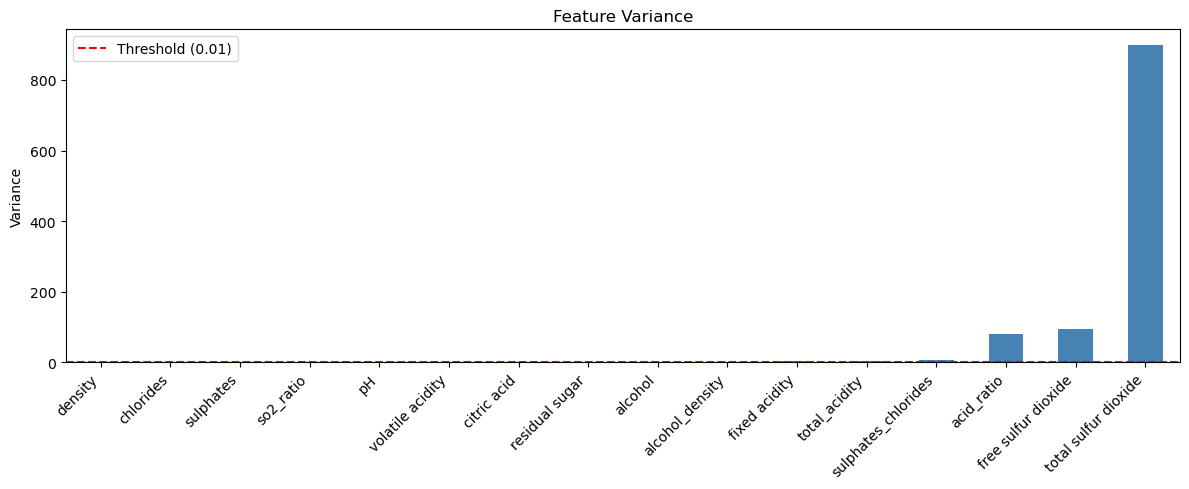


🗑️  Dropped (variance < 0.01): ['chlorides', 'density']
✅ Kept: 14 features


In [13]:
from sklearn.feature_selection import VarianceThreshold

# Identify feature columns (exclude target, Id, and OHE label cols)
exclude = ['quality', 'Id'] + [c for c in df.columns if 'quality_label' in c]
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]

# Compute variance for each feature
variances = df[feature_cols].var().sort_values()
print("=== Feature Variances (ascending) ===")
print(variances.round(6))

# Plot variance bar chart
plt.figure(figsize=(12, 5))
variances.plot(kind='bar', color=['tomato' if v < 0.01 else 'steelblue' for v in variances])
plt.axhline(y=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.title("Feature Variance")
plt.ylabel("Variance")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Drop features below threshold
threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit(df[feature_cols])

dropped = [col for col, keep in zip(feature_cols, selector.get_support()) if not keep]
kept    = [col for col, keep in zip(feature_cols, selector.get_support()) if keep]

print(f"\n🗑️  Dropped (variance < {threshold}): {dropped if dropped else 'None'}")
print(f"✅ Kept: {len(kept)} features")

# Apply the drop
df.drop(columns=dropped, inplace=True)
feature_cols = kept

=== Correlation with Quality (ascending) ===
volatile acidity       -0.405
total sulfur dioxide   -0.207
free sulfur dioxide    -0.061
pH                     -0.056
residual sugar          0.034
total_acidity           0.102
fixed acidity           0.122
so2_ratio               0.193
citric acid             0.242
sulphates               0.339
acid_ratio              0.358
sulphates_chlorides     0.385
alcohol_density         0.488
alcohol                 0.489
Name: quality, dtype: float64


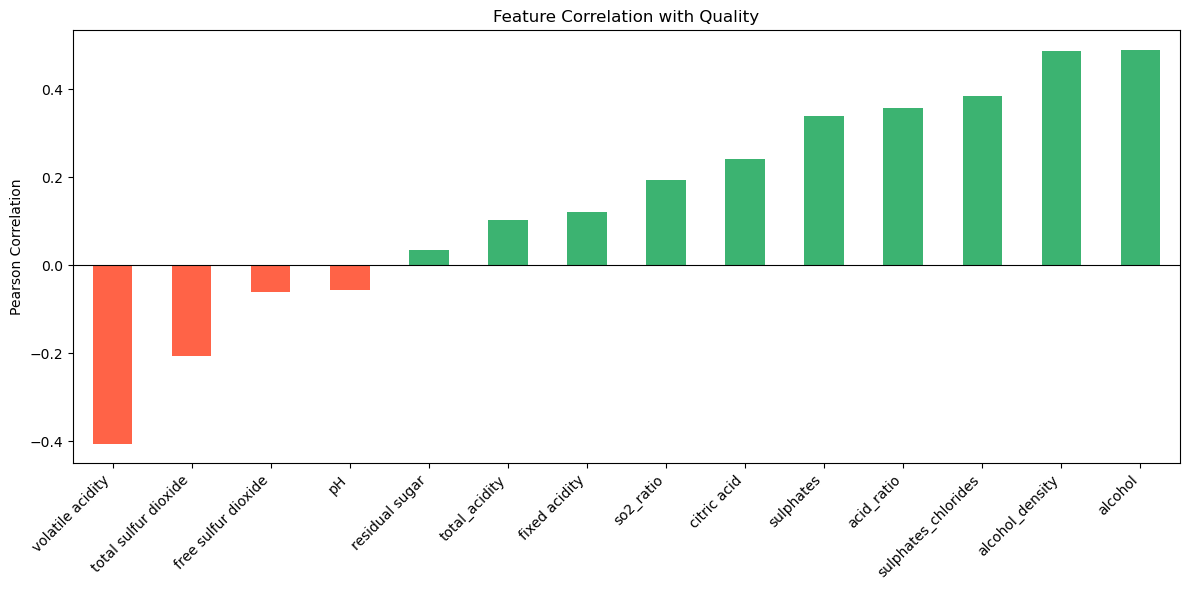


⚠️  Weakly correlated features (|r| < 0.05): ['residual sugar']


In [14]:
# Correlation of all remaining features against the target
corr_with_quality = df[feature_cols + ['quality']].corr()['quality'].drop('quality').sort_values()

print("=== Correlation with Quality (ascending) ===")
print(corr_with_quality.round(3))

# Bar chart
plt.figure(figsize=(12, 6))
colors = ['tomato' if v < 0 else 'mediumseagreen' for v in corr_with_quality]
corr_with_quality.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Quality")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Flag weak correlations (|r| < 0.05)
weak = corr_with_quality[corr_with_quality.abs() < 0.05]
print(f"\n⚠️  Weakly correlated features (|r| < 0.05): {weak.index.tolist()}")

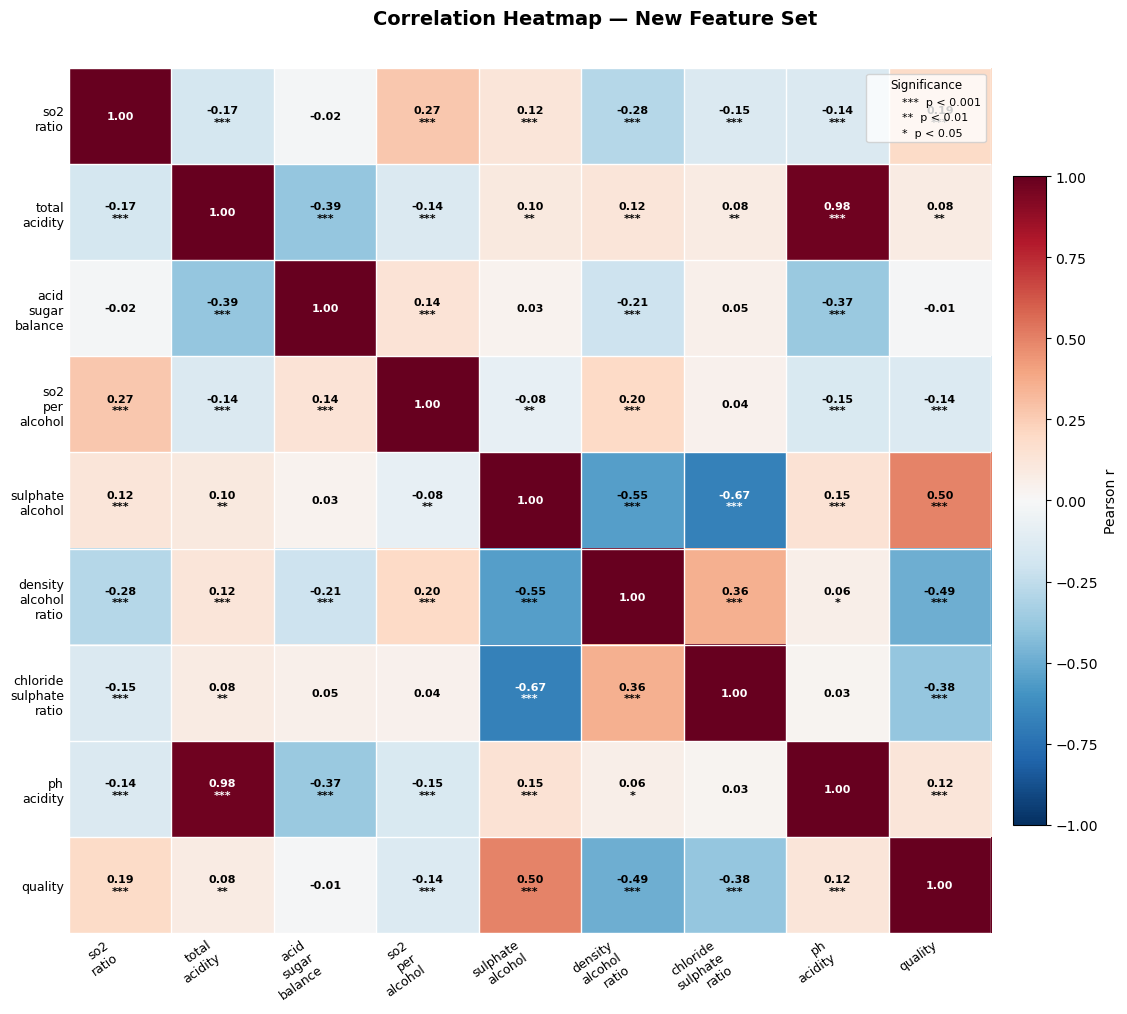

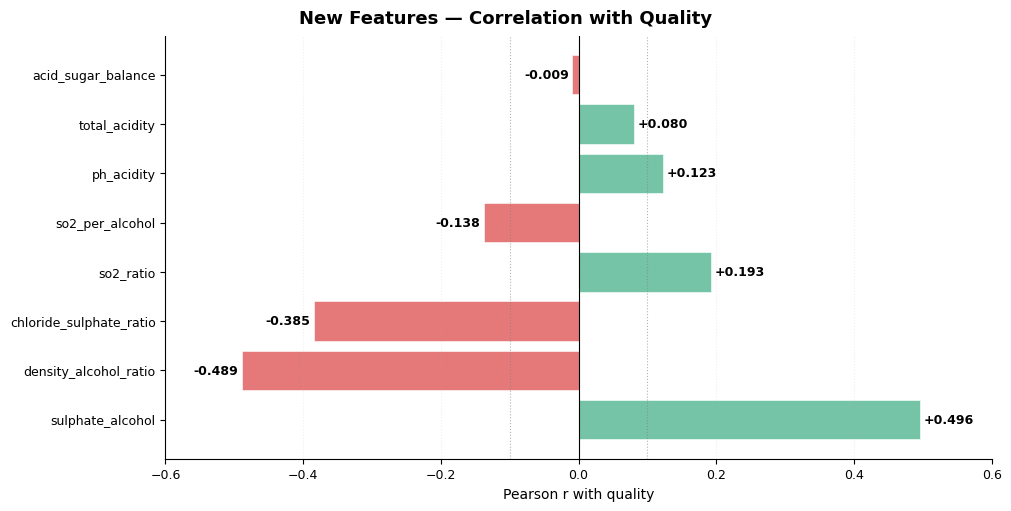


══════════════════════════════════════════════════════════
  CORRELATION WITH QUALITY — new features ranked
══════════════════════════════════════════════════════════
  Feature                            r     p-value  Strength
  ────────────────────────────────────────────────────
  sulphate_alcohol              +0.496      0.0000  weak ***
  density_alcohol_ratio         -0.489      0.0000  weak ***
  chloride_sulphate_ratio       -0.385      0.0000  weak ***
  so2_ratio                     +0.193      0.0000  negligible ***
  so2_per_alcohol               -0.138      0.0000  negligible ***
  ph_acidity                    +0.123      0.0000  negligible ***
  total_acidity                 +0.080      0.0067  none **
  acid_sugar_balance            -0.009      0.7616  none 
══════════════════════════════════════════════════════════



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ── Load & prep ────────────────────────────────────────────────────────────
df = pd.read_csv('WineQT.csv')
df = df.drop(columns=['Id'])

def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    return Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1)

features = [c for c in df.select_dtypes(include=np.number).columns if c != 'quality']
for feat in features:
    lo, hi = iqr_bounds(df[feat])
    df[feat] = df[feat].clip(lower=lo, upper=hi)

# ── Recreate new features ──────────────────────────────────────────────────
df['so2_ratio']              = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
df['total_acidity']          = df['fixed acidity'] + df['volatile acidity']
df['acid_sugar_balance']     = df['residual sugar'] / (df['total_acidity'] + 1e-6)
df['so2_per_alcohol']        = df['free sulfur dioxide'] / (df['alcohol'] + 1e-6)
df['sulphate_alcohol']       = df['sulphates'] * df['alcohol']
df['density_alcohol_ratio']  = df['density'] / (df['alcohol'] + 1e-6)
df['chloride_sulphate_ratio']= df['chlorides'] / (df['sulphates'] + 1e-6)
df['ph_acidity']             = df['pH'] * df['fixed acidity']

new_features = [
    'so2_ratio', 'total_acidity', 'acid_sugar_balance',
    'so2_per_alcohol', 'sulphate_alcohol',
    'density_alcohol_ratio', 'chloride_sulphate_ratio', 'ph_acidity'
]

# Full feature set: original + new + target
all_cols  = new_features + ['quality']
df_new    = df[all_cols].copy()
n         = len(all_cols)

# ── Clean labels ───────────────────────────────────────────────────────────
def clean(col):
    return col.replace('_', '\n')

labels = [clean(c) for c in all_cols]

# ── Pearson r + p-value matrix ─────────────────────────────────────────────
r_mat = np.ones((n, n))
p_mat = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            r, p = pearsonr(df_new.iloc[:, i], df_new.iloc[:, j])
            r_mat[i, j] = r
            p_mat[i, j] = p

def sig_stars(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    return ''

# ══════════════════════════════════════════════════════════════════════════
# PLOT 1 — Full correlation heatmap (new features + quality)
# ══════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(12, 10))
fig1.suptitle('Correlation Heatmap — New Feature Set',
              fontsize=14, fontweight='bold', y=1.01)

im = ax1.imshow(r_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax1, shrink=0.75, label='Pearson r', pad=0.02)

for x in np.arange(-0.5, n, 1):
    ax1.axhline(x, color='white', linewidth=1.0)
    ax1.axvline(x, color='white', linewidth=1.0)

for i in range(n):
    for j in range(n):
        r      = r_mat[i, j]
        stars  = sig_stars(p_mat[i, j]) if i != j else ''
        txt    = f'{r:.2f}\n{stars}' if stars else f'{r:.2f}'
        tc     = 'white' if abs(r) > 0.65 else 'black'
        ax1.text(j, i, txt, ha='center', va='center',
                 fontsize=8, fontweight='bold', color=tc)

ax1.set_xticks(range(n))
ax1.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax1.set_yticks(range(n))
ax1.set_yticklabels(labels, fontsize=9)
ax1.spines[:].set_visible(False)
ax1.tick_params(length=0)

# Significance legend
for s, lbl in [('***', 'p < 0.001'), ('**', 'p < 0.01'), ('*', 'p < 0.05')]:
    ax1.plot([], [], ' ', label=f'{s}  {lbl}')
ax1.legend(loc='upper right', fontsize=8, framealpha=0.8,
           title='Significance', title_fontsize=8.5)

plt.tight_layout()
plt.savefig('corr_new_features.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# PLOT 2 — Correlation with quality only (bar chart)
# ══════════════════════════════════════════════════════════════════════════
corr_quality = {col: r_mat[i, all_cols.index('quality')]
                for i, col in enumerate(all_cols) if col != 'quality'}
corr_sorted  = dict(sorted(corr_quality.items(), key=lambda x: abs(x[1]), reverse=True))

fig2, ax2 = plt.subplots(figsize=(10, 5), constrained_layout=True)
fig2.suptitle('New Features — Correlation with Quality',
              fontsize=13, fontweight='bold')

colors = ['#57B894' if v >= 0 else '#E05C5C' for v in corr_sorted.values()]
bars   = ax2.barh(list(corr_sorted.keys()), list(corr_sorted.values()),
                  color=colors, alpha=0.82, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, corr_sorted.values()):
    ax2.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height() / 2,
             f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

ax2.axvline(0,    color='black', linewidth=0.8)
ax2.axvline( 0.1, color='gray',  linewidth=0.8, linestyle=':', alpha=0.6)
ax2.axvline(-0.1, color='gray',  linewidth=0.8, linestyle=':', alpha=0.6)
ax2.set_xlabel('Pearson r with quality', fontsize=10)
ax2.set_xlim(-0.6, 0.6)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', alpha=0.2, linestyle=':')
ax2.tick_params(labelsize=9)

plt.savefig('corr_new_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# CONSOLE REPORT
# ══════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*58}")
print(f"  CORRELATION WITH QUALITY — new features ranked")
print(f"{'═'*58}")
print(f"  {'Feature':<28} {'r':>7}  {'p-value':>10}  Strength")
print(f"  {'─'*52}")

def strength(r):
    a = abs(r)
    if   a >= 0.5: return 'moderate'
    elif a >= 0.3: return 'weak'
    elif a >= 0.1: return 'negligible'
    return 'none'

for feat, r in corr_sorted.items():
    idx = all_cols.index(feat)
    p   = p_mat[idx, all_cols.index('quality')]
    print(f"  {feat:<28} {r:>+7.3f}  {p:>10.4f}  "
          f"{strength(r)} {sig_stars(p)}")

print(f"{'═'*58}\n")

In [19]:
import datetime

summary = f"""
# Feature Engineering Summary
Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}

## New Features Created
| Feature                | Description                                          |
|------------------------|------------------------------------------------------|
| so2_ratio              | Free SO₂ / Total SO₂ — active preservation ratio   |
| total_acidity          | Fixed + Volatile + Citric acid combined              |
| acid_ratio             | Fixed acidity / Volatile acidity                    |
| alcohol_density        | Alcohol / Density — body and strength index         |
| sulphates_chlorides    | Sulphates / Chlorides — preservation vs saltiness   |

## Binned Features
- alcohol_bin        → Low / Medium / High  (thresholds: 9.5, 11.1)
- sulphates_bin      → Low / Medium / High  (thresholds: 0.55, 0.73)
- volatile_acidity_bin → Low / Medium / High (thresholds: 0.39, 0.64)

## Low Variance
- Threshold: 0.01
- Dropped: {dropped if dropped else 'None'}

## Top Correlated Features with Quality
{corr_with_quality.tail(5).round(3).to_string()}
"""

with open("FEATURE_ENGINEERING.md", "w") as f:
    f.write(summary)

print("✅ Documentation saved to FEATURE_ENGINEERING.md")
print(summary)

✅ Documentation saved to FEATURE_ENGINEERING.md

# Feature Engineering Summary
Generated: 2026-04-04 15:14

## New Features Created
| Feature                | Description                                          |
|------------------------|------------------------------------------------------|
| so2_ratio              | Free SO₂ / Total SO₂ — active preservation ratio   |
| total_acidity          | Fixed + Volatile + Citric acid combined              |
| acid_ratio             | Fixed acidity / Volatile acidity                    |
| alcohol_density        | Alcohol / Density — body and strength index         |
| sulphates_chlorides    | Sulphates / Chlorides — preservation vs saltiness   |

## Binned Features
- alcohol_bin        → Low / Medium / High  (thresholds: 9.5, 11.1)
- sulphates_bin      → Low / Medium / High  (thresholds: 0.55, 0.73)
- volatile_acidity_bin → Low / Medium / High (thresholds: 0.39, 0.64)

## Low Variance
- Threshold: 0.01
- Dropped: ['chlorides', 'density']



<class 'OSError'>: [Errno 138] emscripten does not support processes.